# Evaluando la Creatividad Artificial: Métricas y Reflexión



## 1. Instalación de dependencias




In [6]:
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q torch torchvision pillow numpy matplotlib scikit-image


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00


## 2. Importar librerías

In [7]:
import clip
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage.metrics import structural_similarity as ssim


## 3. Cargar modelo CLIP

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

print("Dispositivo:", device)


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 83.1MiB/s]


Dispositivo: cpu


## 4. Subir imágenes generadas por IA


In [10]:
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())


Saving 3.jpg to 3.jpg
Saving 2.jpg to 2.jpg
Saving 1.jpg to 1 (1).jpg
dict_keys(['3.jpg', '2.jpg', '1 (1).jpg'])


## 5. Visualizar imágenes cargadas

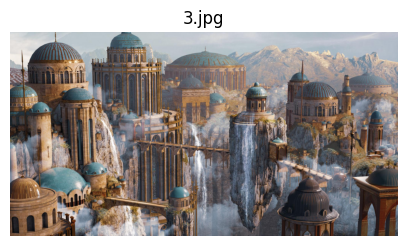

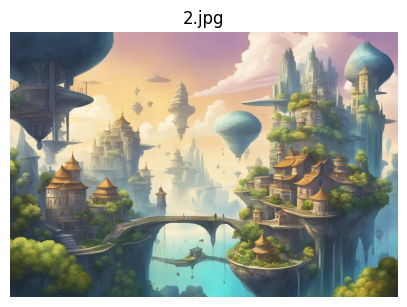

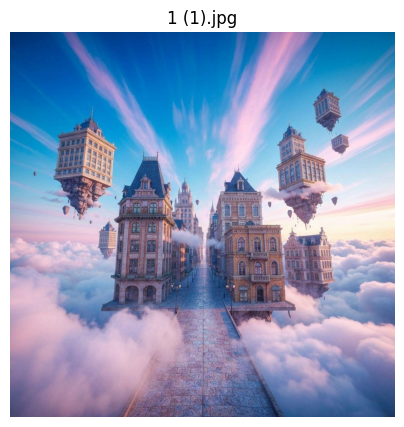

In [11]:
imagenes = list(uploaded.keys())

for img_name in imagenes:
    img = Image.open(img_name)
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")
    plt.show()


## 6. Definir el prompt utilizado

In [12]:
prompt = "a surreal dreamscape with floating cities"
print(prompt)


a surreal dreamscape with floating cities


## 7. Calcular CLIPScore

Esta métrica mide qué tan alineada está la imagen con el texto.


In [14]:
def calcular_clipscore(imagen_path, prompt):
    image = preprocess(Image.open(imagen_path)).unsqueeze(0).to(device)
    text = clip.tokenize([prompt]).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image)
        text_features = model.encode_text(text)

        score = torch.cosine_similarity(
            image_features,
            text_features
        ).item()

    return score


In [15]:
resultados = []

for img in imagenes:
    score = calcular_clipscore(img, prompt)
    resultados.append([img, score])

resultados


[['3.jpg', 0.3008391857147217],
 ['2.jpg', 0.3294811248779297],
 ['1 (1).jpg', 0.31344494223594666]]

## 8. Evaluar simetría visual

Se compara la mitad izquierda con la mitad derecha usando SSIM.


In [16]:
def calcular_simetria(imagen_path):
    img = Image.open(imagen_path).convert("L")

    img = np.array(img)

    mitad = img.shape[1] // 2

    izquierda = img[:, :mitad]
    derecha = np.fliplr(img[:, -mitad:])

    h = min(izquierda.shape[0], derecha.shape[0])
    w = min(izquierda.shape[1], derecha.shape[1])

    izquierda = izquierda[:h, :w]
    derecha = derecha[:h, :w]

    score, _ = ssim(
        izquierda,
        derecha,
        full=True
    )

    return score


In [17]:
for img in imagenes:
    simetria = calcular_simetria(img)
    print(f"{img}: {simetria:.4f}")


3.jpg: 0.2367
2.jpg: 0.3897
1 (1).jpg: 0.4985


## 9. Comparar resultados en una tabla

In [18]:
tabla = []

for img in imagenes:
    tabla.append({
        "Imagen": img,
        "CLIPScore": calcular_clipscore(img, prompt),
        "Simetria": calcular_simetria(img)
    })

import pandas as pd

df = pd.DataFrame(tabla)
df.sort_values("CLIPScore", ascending=False)


,Imagen,CLIPScore,Simetria
1,2.jpg,0.329481,0.389741
2,1 (1).jpg,0.313445,0.498525
0,3.jpg,0.300839,0.236703


## 10. Visualización de métricas

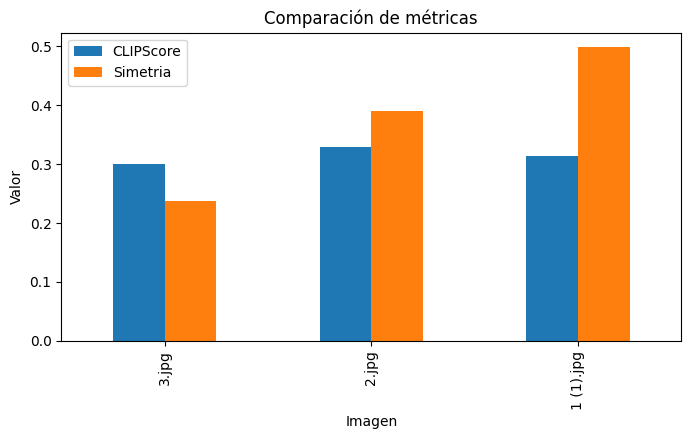

In [19]:
df.set_index("Imagen")[["CLIPScore", "Simetria"]].plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Comparación de métricas")
plt.ylabel("Valor")
plt.show()
